In [5]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'catvs dog.zip', 'sample_data']


In [6]:
import zipfile

with zipfile.ZipFile('/content/catvs dog.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted!")

Dataset Extracted!


In [7]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'val.csv', 'train', 'catvs dog.zip', 'train.csv', 'val', 'sample_data']


In [8]:
import os

print(os.listdir('/content/train')[:20])

['classname.txt', 'cat', 'dog']


Dataset Loaded
X Shape: (275, 2500)
Y Shape: (275,)
Training SVM...

Accuracy: 0.41818181818181815

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.26      0.24        19
           1       0.56      0.50      0.53        36

    accuracy                           0.42        55
   macro avg       0.39      0.38      0.38        55
weighted avg       0.44      0.42      0.43        55



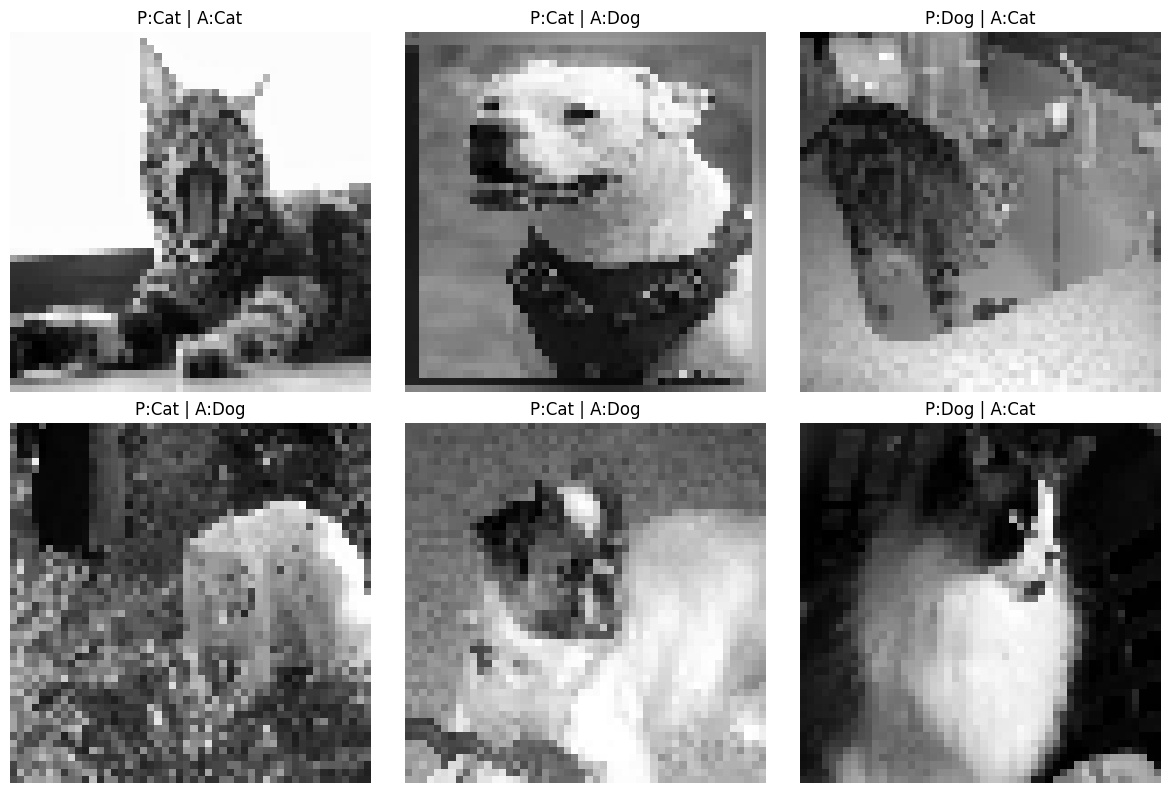

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Dataset paths
cat_path = "/content/train/cat"
dog_path = "/content/train/dog"

data = []
labels = []

# Load Cat Images
for file in os.listdir(cat_path)[:500]:
    img = cv2.imread(os.path.join(cat_path, file), cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (50, 50))
        data.append(img.flatten())
        labels.append(0)   # Cat

# Load Dog Images
for file in os.listdir(dog_path)[:500]:
    img = cv2.imread(os.path.join(dog_path, file), cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (50, 50))
        data.append(img.flatten())
        labels.append(1)   # Dog

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print("Dataset Loaded")
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train SVM
svm = SVC(kernel='linear')

print("Training SVM...")
svm.fit(X_train, y_train)

# Predictions
y_pred = svm.predict(X_test)

# Results
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Visual Predictions
indices = random.sample(range(len(X_test)), 6)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):

    plt.subplot(2,3,i+1)

    img = X_test[idx].reshape(50,50)

    pred = svm.predict([X_test[idx]])[0]
    actual = y_test[idx]

    pred_label = "Dog" if pred == 1 else "Cat"
    actual_label = "Dog" if actual == 1 else "Cat"

    plt.imshow(img, cmap='gray')
    plt.title(f"P:{pred_label} | A:{actual_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()